<img width=200 height=100 src="iris.png" />

In [1]:
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns 

In [13]:
from sklearn.datasets import load_iris
iris=load_iris(as_frame=True)
df=iris.data
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [14]:
df=iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [25]:
df["target_name"]=df["target"].map({0:'setosa',1:'versicolor',2:'virginica'})

In [26]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [18]:
df.shape

(150, 5)

In [19]:
df.target.unique()

array([0, 1, 2])

In [20]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [24]:
# print(iris.DESCR)

In [23]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

## Data Visualization and exploration 

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

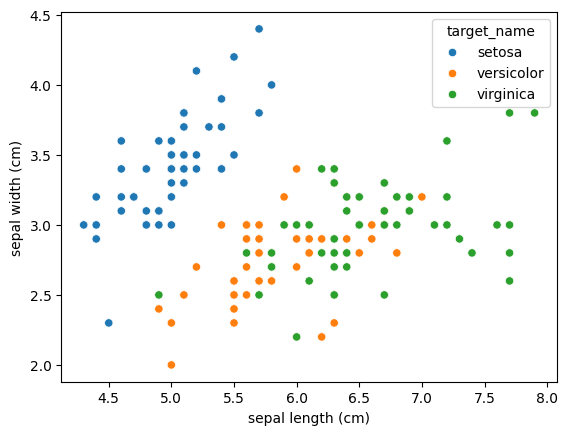

In [28]:
sns.scatterplot(df,x="sepal length (cm)",y="sepal width (cm)",hue="target_name")

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

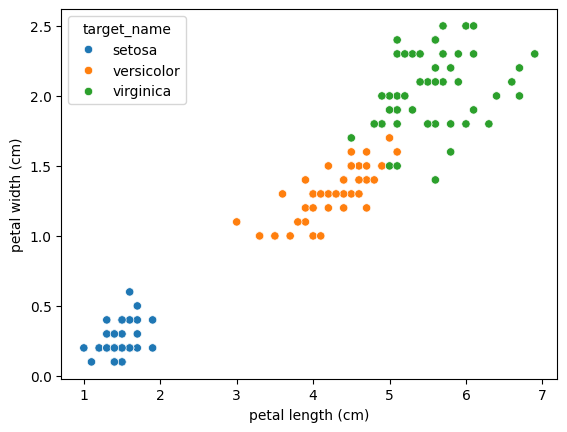

In [29]:
sns.scatterplot(df,x="petal length (cm)",y="petal width (cm)",hue="target_name")

In [30]:
X=df[["sepal length (cm)",	"sepal width (cm)",	"petal length (cm)",	"petal width (cm)"]]
y=df["target"]
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Model Traning


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.3,random_state=5)


In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
model=LogisticRegression()

In [37]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model Evaluation 

In [39]:
model.score(X_test,y_test)

0.9777777777777777

In [40]:
y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9777777777777777

In [42]:
y_pred[:10]

array([1, 2, 2, 0, 2, 1, 0, 2, 0, 1])

In [43]:
y_test[:10]

82     1
134    2
114    2
42     0
109    2
57     1
1      0
70     1
25     0
84     1
Name: target, dtype: int64

In [45]:
y_test[:10].tolist()

[1, 2, 2, 0, 2, 1, 0, 1, 0, 1]

In [46]:
y_pred[:10].tolist()

[1, 2, 2, 0, 2, 1, 0, 2, 0, 1]

## Model evaluation using precision recall accuracy

In [48]:
from sklearn.metrics import classification_report


In [50]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.94      0.97        16
           2       0.93      1.00      0.97        14

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## Model evaluation using confusion matrix


In [52]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)

Text(0.5, 1.0, 'Confusion Matrix')

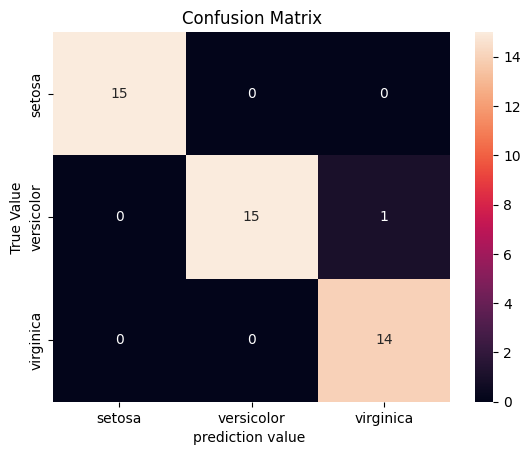

In [60]:
sns.heatmap(cm,xticklabels=iris.target_names,yticklabels=iris.target_names,annot=True)
plt.xlabel("prediction value ")
plt.ylabel(" True Value ")
plt.title("Confusion Matrix")